# Exploratory Data Analysis — Gift Recommendation Catalogue

Analyses the cleaned catalogue produced by `01_data_cleaning.ipynb`.

**Purpose.** This notebook is the specification input for the modelling team.
Every section ends with a finding stated as a decision they must make, not as an
observation. Section 15 collects those findings into a single table.

| Input | Rows |
|---|---|
| `catalog_clean.csv` | one row per product |
| `catalog_offers.csv` | one row per purchasable option |
| `signal_weights.csv` | inverse-frequency weights per label |

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

DATA_DIR = Path("data/processed")
FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = "crest"
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})


def save(fig: plt.Figure, name: str) -> None:
    fig.savefig(FIG_DIR / f"{name}.png")

In [2]:
products = pd.read_csv(DATA_DIR / "catalog_clean.csv", encoding="utf-8-sig")
offers = pd.read_csv(DATA_DIR / "catalog_offers.csv", encoding="utf-8-sig")
weights = pd.read_csv(DATA_DIR / "signal_weights.csv", encoding="utf-8-sig", index_col="label")

OCC_COLS = [c for c in products.columns if c.startswith("occ_")]
INT_COLS = [c for c in products.columns if c.startswith("int_")]
OCCASIONS = [c[4:] for c in OCC_COLS]
INTERESTS = [c[4:] for c in INT_COLS]

print(f"products : {len(products):,} rows x {products.shape[1]} columns")
print(f"offers   : {len(offers):,} rows")
print(f"occasions: {len(OCCASIONS)}   interests: {len(INTERESTS)}")

products : 45,055 rows x 54 columns
offers   : 55,069 rows
occasions: 10   interests: 15


## 2. Dataset overview

In [3]:
overview = pd.DataFrame({
    "dtype": products.dtypes.astype(str),
    "non_null": products.notna().sum(),
    "missing_%": (products.isna().mean() * 100).round(2),
    "unique": products.nunique(),
    "example": products.iloc[0].astype(str).str.slice(0, 40),
})
overview

,dtype,non_null,missing_%,unique,example
parent_id,str,45055,0.00,45055,PROD-000001
product_name,str,45055,0.00,44820,Roco Standard Staples
brand,str,45055,0.00,1517,Unbranded
category,str,45055,0.00,14,Office & Study
sub_category,str,45055,0.00,67,Office
gift_type,str,45055,0.00,12,Single Product
gender_target,str,45055,0.00,3,Unisex
age_group,str,45055,0.00,7,All Ages
min_age,int64,45055,0.00,4,0
max_age,int64,45055,0.00,4,99


In [4]:
summary = pd.Series({
    "products": len(products),
    "purchase options": len(offers),
    "products with >1 option": int((products["offer_count"] > 1).sum()),
    "categories": products["category"].nunique(),
    "sub-categories": products["sub_category"].nunique(),
    "brands": products["brand"].nunique(),
    "source stores": products["source_site"].nunique(),
    "median price (SAR)": round(products["price_min"].median(), 2),
    "memory (MB)": round(products.memory_usage(deep=True).sum() / 1e6, 1),
}).to_frame("value")
summary

,value
products,45055.0
purchase options,55069.0
products with >1 option,4658.0
categories,14.0
sub-categories,67.0
brands,1517.0
source stores,22.0
median price (SAR),359.0
memory (MB),77.0


## 3. Missing values

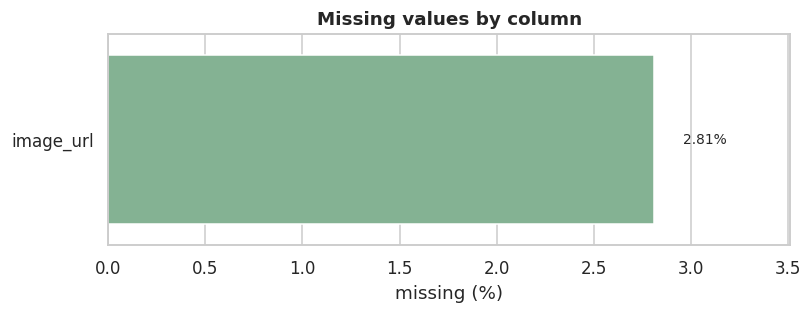

,missing_%
image_url,2.81


In [5]:
missing = (
    products.isna().mean().mul(100).round(2)
    .loc[lambda s: s > 0].sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, max(2.5, 0.42 * len(missing))))
sns.barplot(x=missing.values, y=missing.index, ax=ax, hue=missing.index, legend=False)
for i, v in enumerate(missing.values):
    ax.text(v + 0.15, i, f"{v:.2f}%", va="center", fontsize=9)
ax.set(xlabel="missing (%)", ylabel="", title="Missing values by column")
ax.set_xlim(0, max(missing.values) * 1.25)
save(fig, "01_missing_values")
plt.show()

missing.to_frame("missing_%")

**Reading.** Only a handful of columns have gaps and none exceeds a level that
threatens the pipeline. `image_url` gaps are already neutralised by
`image_display_url`, which always resolves to either a real asset or a
placeholder.

**Why it matters.** No column requires imputation. Imputing a price would be
actively harmful, since price is a hard filter and a fabricated value would place
an item inside a budget it does not belong to.

**Improvement.** Re-scrape the affected sources to recover images at source
rather than relying on placeholders.

## 4. Purchase options (variants)

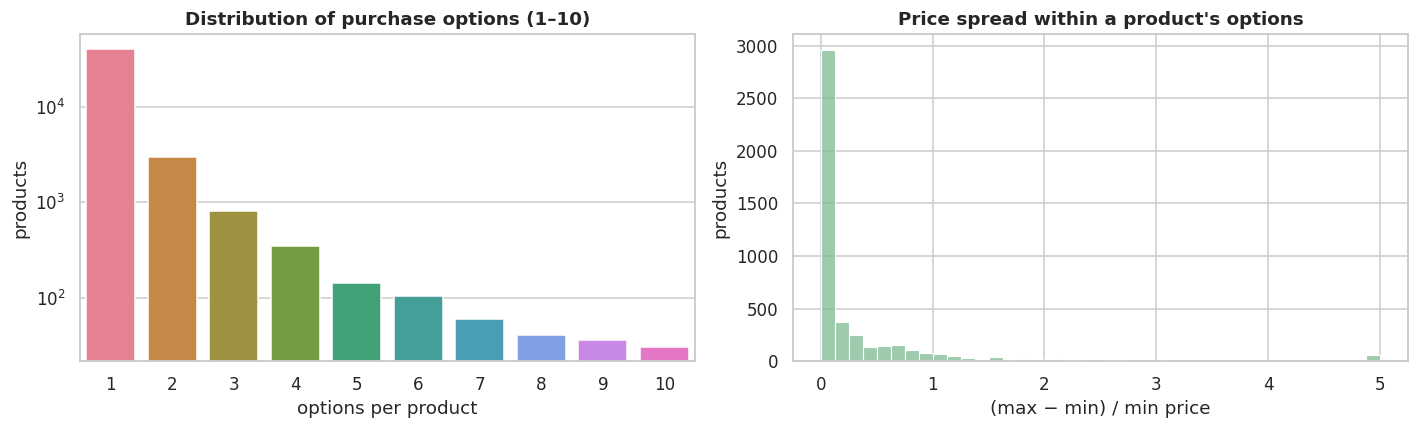

single-option products : 40,397
multi-option products  : 4,658
largest option group   : 104
median price spread    : 0.0%


In [6]:
option_dist = products["offer_count"].value_counts().sort_index()
shown = option_dist[option_dist.index <= 10]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x=shown.index.astype(str), y=shown.values, ax=axes[0],
            hue=shown.index.astype(str), legend=False)
axes[0].set(xlabel="options per product", ylabel="products",
            title="Distribution of purchase options (1–10)")
axes[0].set_yscale("log")

multi = products[products["offer_count"] > 1]
spread = (multi["price_max"] - multi["price_min"]) / multi["price_min"]
sns.histplot(spread.clip(0, 5), bins=40, ax=axes[1])
axes[1].set(xlabel="(max − min) / min price", ylabel="products",
            title="Price spread within a product's options")
plt.tight_layout()
save(fig, "02_purchase_options")
plt.show()

print(f"single-option products : {int((products['offer_count'] == 1).sum()):,}")
print(f"multi-option products  : {len(multi):,}")
print(f"largest option group   : {int(products['offer_count'].max())}")
print(f"median price spread    : {spread.median():.1%}")

**Reading.** The overwhelming majority of products have a single purchase
option; a long tail carries dozens. Within multi-option products the price spread
is usually modest, which is consistent with colour or size variants rather than
distinct products sharing a generic name.

**Why it matters.** Grouping is what stops a result list filling with five
versions of one shoe. The modelling team ranks **products**, and the interface
resolves the chosen product to its options.

**Improvement.** Groups with an extreme price spread are likely distinct products
under a generic name and deserve a manual check.

## 5. Price distribution

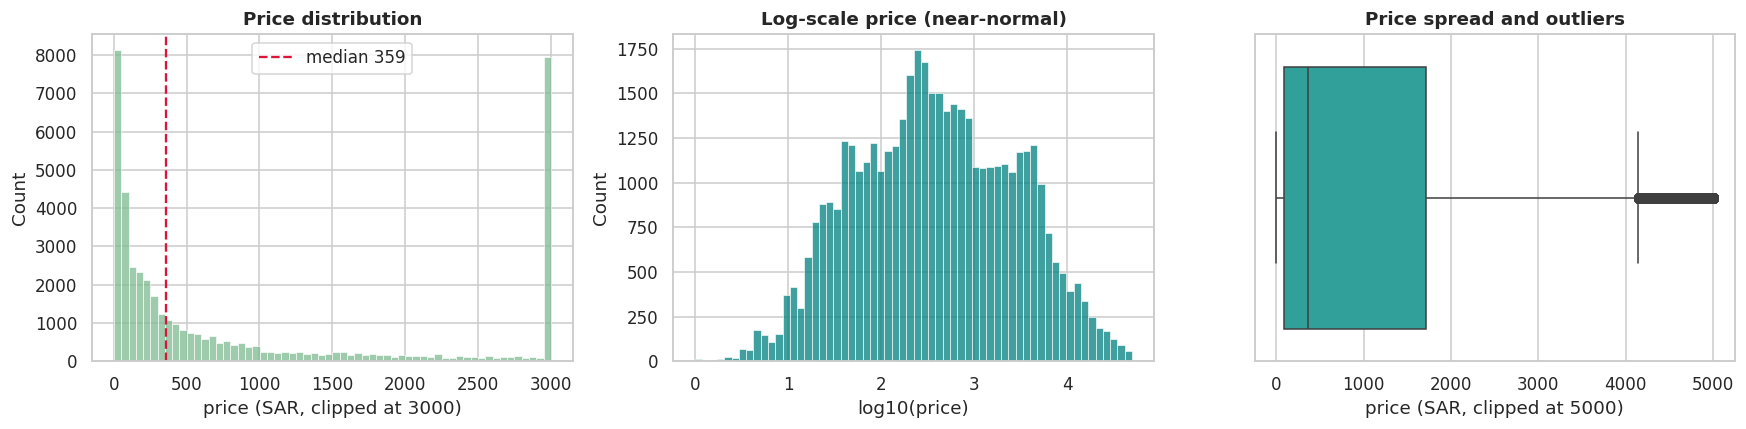

,value
count,45055.00
mean,1951.63
median,359.00
std,4452.74
min,1.00
max,49773.00
skew,4.85
kurtosis,30.63
IQR,1621.00


In [7]:
price = products["price_min"]

stats = pd.Series({
    "count": len(price),
    "mean": price.mean(),
    "median": price.median(),
    "std": price.std(),
    "min": price.min(),
    "max": price.max(),
    "skew": price.skew(),
    "kurtosis": price.kurtosis(),
    "IQR": price.quantile(.75) - price.quantile(.25),
}).round(2).to_frame("value")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(price.clip(0, 3000), bins=60, ax=axes[0])
axes[0].axvline(price.median(), color="crimson", ls="--", label=f"median {price.median():.0f}")
axes[0].legend()
axes[0].set(xlabel="price (SAR, clipped at 3000)", title="Price distribution")

sns.histplot(np.log10(price), bins=60, ax=axes[1], color="teal")
axes[1].set(xlabel="log10(price)", title="Log-scale price (near-normal)")

sns.boxplot(x=price.clip(0, 5000), ax=axes[2], color="lightseagreen")
axes[2].set(xlabel="price (SAR, clipped at 5000)", title="Price spread and outliers")
plt.tight_layout()
save(fig, "03_price_distribution")
plt.show()

stats

**Reading.** Price is heavily right-skewed: the mean sits far above the median
because a small number of luxury items pull it up. On a log scale the
distribution is close to normal, which is typical of retail pricing.

**Why it matters.** Any model using raw price as a numeric feature will be
dominated by the tail. The modelling team should either log-transform price or
use the ordinal `price_band`. Distance metrics on raw price will be meaningless.

**Improvement.** Treat `price_band` as the primary price feature and keep the raw
value only for the hard budget filter.

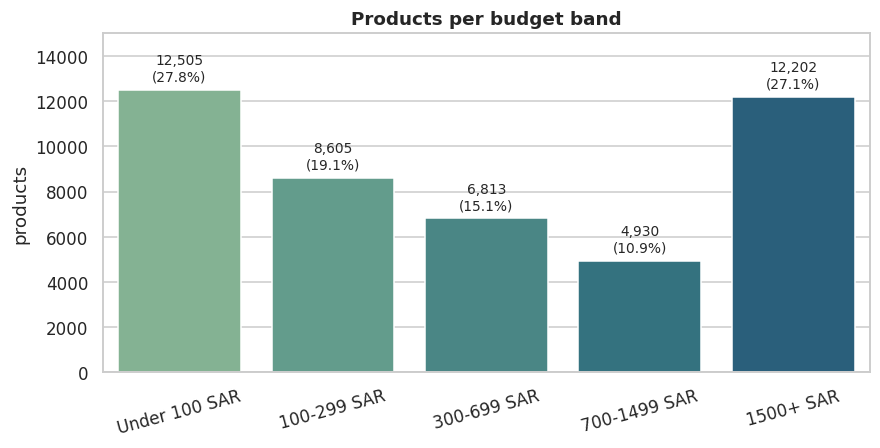

,products,share
price_band,,
Under 100 SAR,12505,27.8
100-299 SAR,8605,19.1
300-699 SAR,6813,15.1
700-1499 SAR,4930,10.9
1500+ SAR,12202,27.1


In [8]:
order = ["Under 100 SAR", "100-299 SAR", "300-699 SAR", "700-1499 SAR", "1500+ SAR"]
band = products["price_band"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=band.index, y=band.values, ax=ax, hue=band.index, legend=False)
for i, v in enumerate(band.values):
    ax.text(i, v + 400, f"{v:,}\n({v / len(products) * 100:.1f}%)",
            ha="center", fontsize=9)
ax.set(xlabel="", ylabel="products", title="Products per budget band")
ax.set_ylim(0, band.max() * 1.2)
plt.xticks(rotation=15)
save(fig, "04_price_bands")
plt.show()

band.to_frame("products").assign(share=lambda d: (d["products"] / len(products) * 100).round(1))

**Reading.** Supply is concentrated in the lower and middle bands, which
matches realistic gift budgets.

**Why it matters.** Budget is a hard filter, so a thin band means a thin candidate
pool for those users. Any band holding a small share of the catalogue is a
coverage risk for the queries that land in it.

**Improvement.** Track candidate-pool size per band during evaluation; if any band
routinely yields fewer than roughly fifty candidates, expand the catalogue there
before tuning the model.

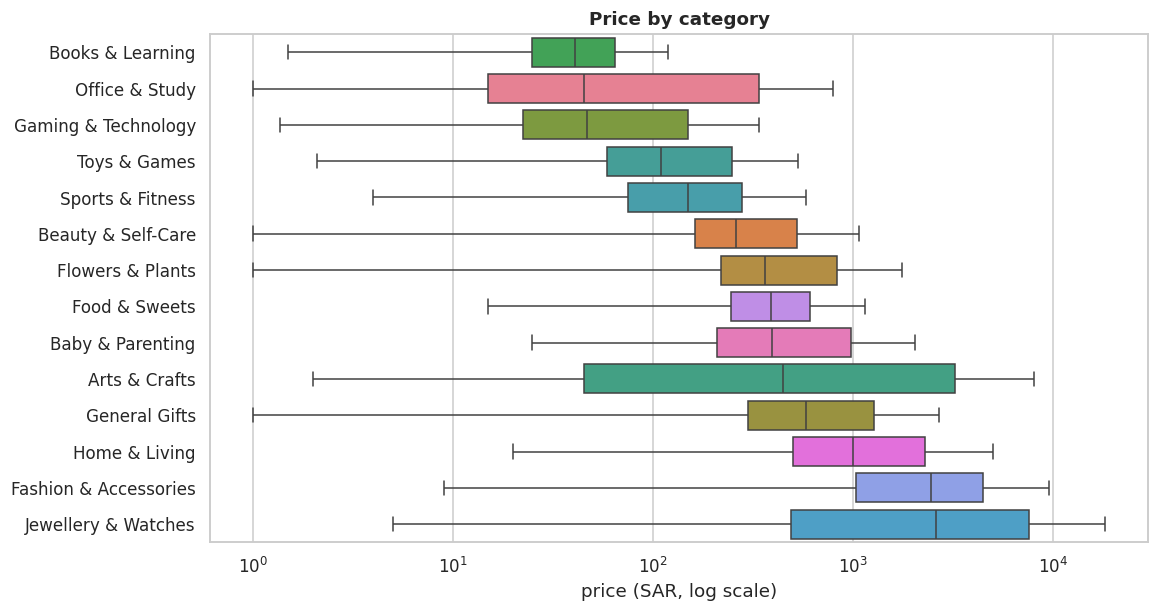

,count,median,mean,max
category,,,,
Books & Learning,1526,41.0,140.0,20850.0
Office & Study,347,45.0,317.0,4658.0
Gaming & Technology,8727,47.0,434.0,29999.0
Toys & Games,4658,109.0,281.0,15550.0
Sports & Fitness,2516,149.0,264.0,9199.0
Beauty & Self-Care,5045,261.0,486.0,28219.0
Flowers & Plants,280,362.0,894.0,12734.0
Food & Sweets,1316,389.0,514.0,4158.0
Baby & Parenting,206,395.0,983.0,18715.0


In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
order_cat = products.groupby("category")["price_min"].median().sort_values().index
sns.boxplot(data=products, y="category", x="price_min", order=order_cat,
            ax=ax, showfliers=False, hue="category", legend=False)
ax.set_xscale("log")
ax.set(xlabel="price (SAR, log scale)", ylabel="", title="Price by category")
save(fig, "05_price_by_category")
plt.show()

products.groupby("category")["price_min"].agg(["count", "median", "mean", "max"]).round(0).sort_values("median")

**Reading.** Median price varies by more than an order of magnitude across
categories, and the spread within some categories is very wide.

**Why it matters.** A global price-fit score is misleading: 200 SAR is generous
for one category and minimal for another. The modelling team should normalise
price **within category** when scoring how well a gift uses the budget.

**Improvement.** Replace the global price-fit term with a within-category
percentile rank.

## 6. Categories and sub-categories

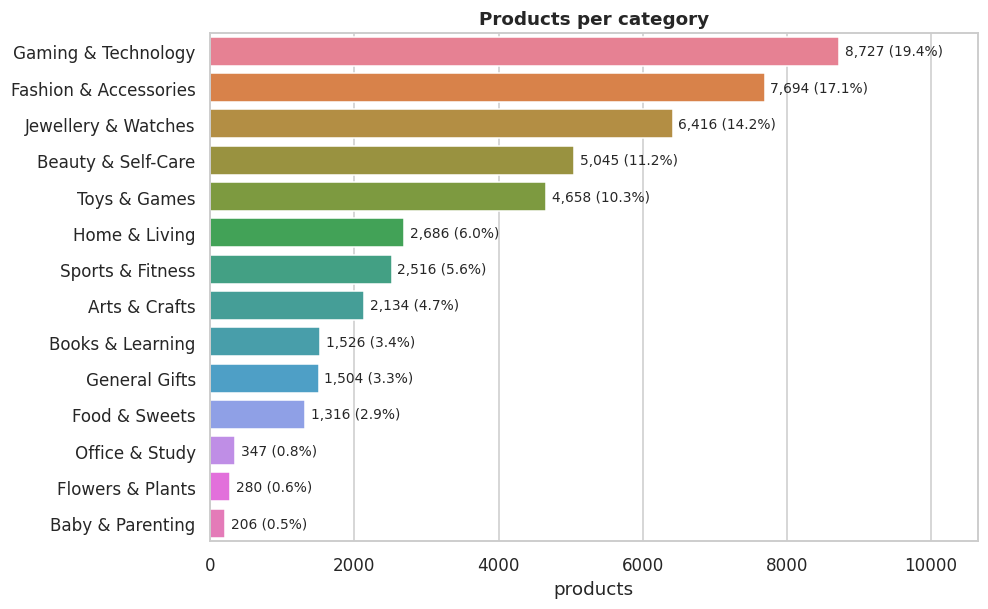

largest / smallest category ratio: 42.4x


,products
category,
Gaming & Technology,8727
Fashion & Accessories,7694
Jewellery & Watches,6416
Beauty & Self-Care,5045
Toys & Games,4658
Home & Living,2686
Sports & Fitness,2516
Arts & Crafts,2134
Books & Learning,1526


In [10]:
cat = products["category"].value_counts()

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=cat.values, y=cat.index, ax=ax, hue=cat.index, legend=False)
for i, v in enumerate(cat.values):
    ax.text(v + 80, i, f"{v:,} ({v / len(products) * 100:.1f}%)", va="center", fontsize=9)
ax.set(xlabel="products", ylabel="", title="Products per category")
ax.set_xlim(0, cat.max() * 1.22)
save(fig, "06_categories")
plt.show()

imbalance = cat.max() / cat.min()
print(f"largest / smallest category ratio: {imbalance:.1f}x")
cat.to_frame("products")

**Reading.** Category sizes are highly unequal; the largest holds many times
the volume of the smallest.

**Why it matters.** This is class imbalance. Any classifier trained on category
will favour the majority classes, and a similarity-based ranker will surface them
disproportionately simply because there are more of them. Accuracy would be a
misleading metric here.

**Improvement.** Report macro-averaged metrics, apply class weights, and enforce a
per-category cap in the ranker so the head categories cannot monopolise results.

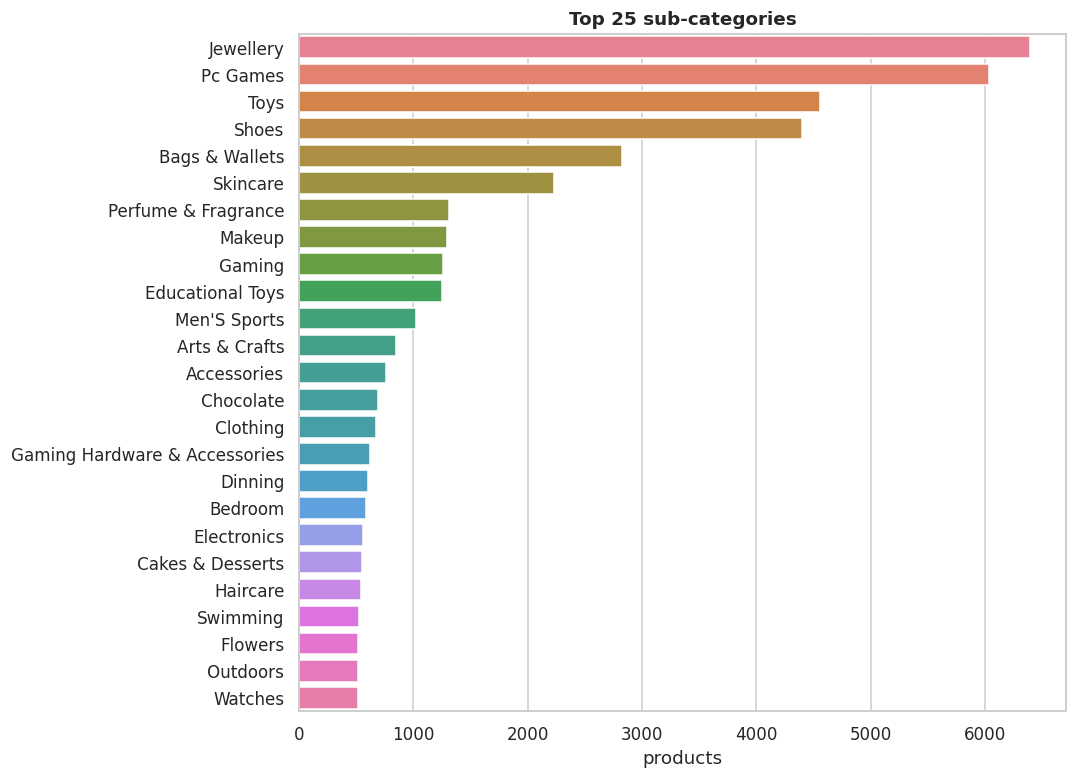

total sub-categories: 67
share held by top 25: 91.2%


In [11]:
top_sub = products["sub_category"].value_counts().head(25)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(x=top_sub.values, y=top_sub.index, ax=ax, hue=top_sub.index, legend=False)
ax.set(xlabel="products", ylabel="", title="Top 25 sub-categories")
save(fig, "07_subcategories")
plt.show()

print(f"total sub-categories: {products['sub_category'].nunique()}")
print(f"share held by top 25: {top_sub.sum() / len(products) * 100:.1f}%")

**Reading.** A minority of sub-categories accounts for most of the catalogue,
leaving a long tail with very few products each.

**Why it matters.** Sub-category is the strongest available signal for interest
derivation, but the tail is too thin to learn from. Treat rare sub-categories as a
single "other" bucket rather than as individual classes.

**Improvement.** Merge sub-categories below a minimum count into their parent
category.

## 7. Recipient demographics

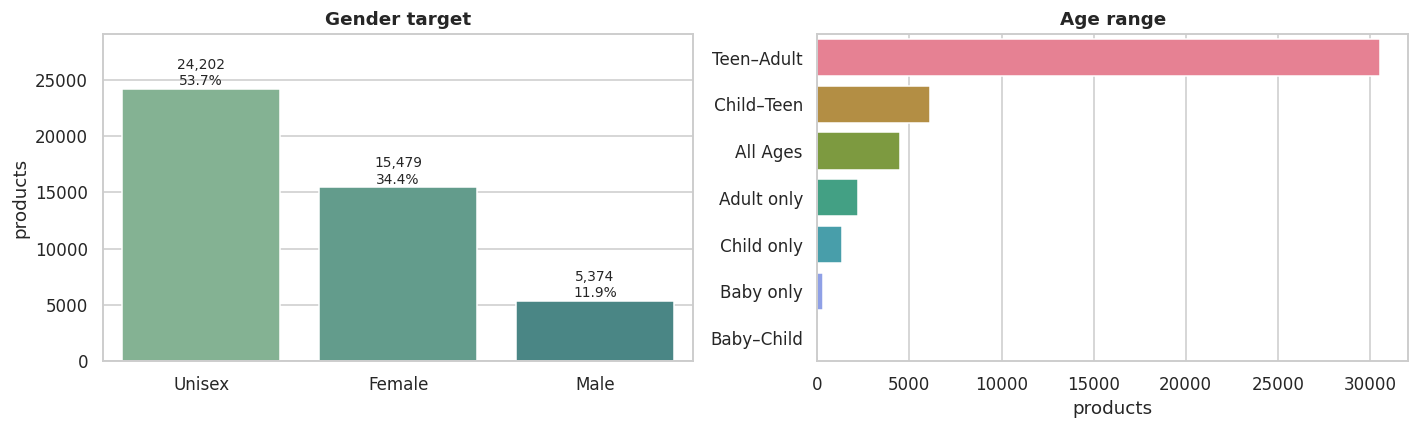

,products,axis
Unisex,24202,gender
Female,15479,gender
Male,5374,gender
Teen–Adult,30542,age
Child–Teen,6141,age
All Ages,4464,age
Adult only,2220,age
Child only,1356,age
Baby only,312,age
Baby–Child,20,age


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

gender = products["gender_target"].value_counts()
sns.barplot(x=gender.index, y=gender.values, ax=axes[0],
            hue=gender.index, legend=False)
for i, v in enumerate(gender.values):
    axes[0].text(i, v + 300, f"{v:,}\n{v / len(products) * 100:.1f}%",
                 ha="center", fontsize=9)
axes[0].set(xlabel="", ylabel="products", title="Gender target")
axes[0].set_ylim(0, gender.max() * 1.2)

age = products["age_group"].value_counts()
sns.barplot(x=age.values, y=age.index, ax=axes[1], hue=age.index, legend=False)
axes[1].set(xlabel="products", ylabel="", title="Age range")
plt.tight_layout()
save(fig, "08_demographics")
plt.show()

pd.concat([gender.to_frame("products").assign(axis="gender"),
           age.to_frame("products").assign(axis="age")])

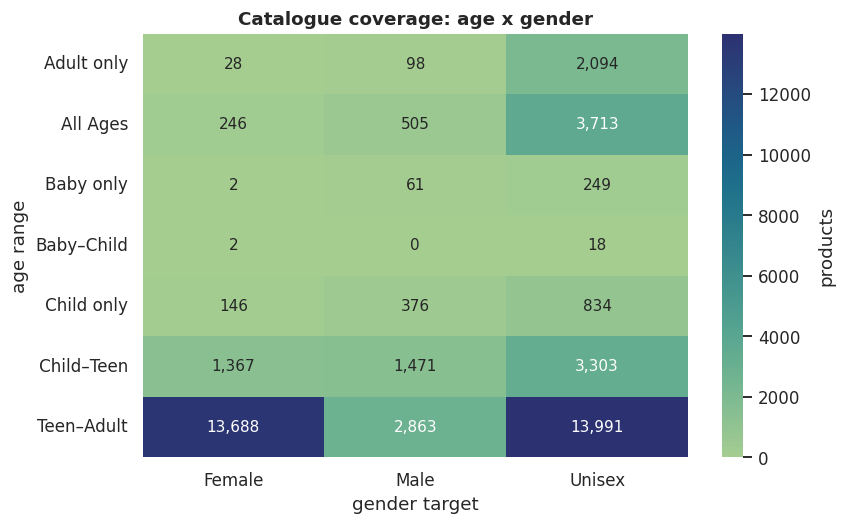

cells with fewer than 100 products:


products
age_group  gender_target          
Adult only Female               28
           Male                 98
Baby only  Female                2
           Male                 61
Baby–Child Female                2
           Male                  0
           Unisex               18

In [13]:
crosstab = pd.crosstab(products["age_group"], products["gender_target"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(crosstab, annot=True, fmt=",d", cmap="crest", ax=ax,
            cbar_kws={"label": "products"})
ax.set(xlabel="gender target", ylabel="age range",
       title="Catalogue coverage: age x gender")
save(fig, "09_age_gender_heatmap")
plt.show()

print("cells with fewer than 100 products:")
thin = crosstab.stack().loc[lambda s: s < 100]
thin.to_frame("products")

**Reading.** Coverage is far from uniform across the age–gender grid. Some
cells hold tens of thousands of products while others hold almost none.

**Why it matters.** These are the queries the system will answer badly. A thin
cell means the hard filter leaves few candidates, so ranking quality barely
matters — there is nothing good to rank.

**Improvement.** Evaluate per cell, not only in aggregate. An overall Precision@5
can look healthy while specific recipient types are served poorly. Any cell below
roughly one hundred products should be treated as a known limitation and, ideally,
filled by targeted collection.

## 8. Occasions

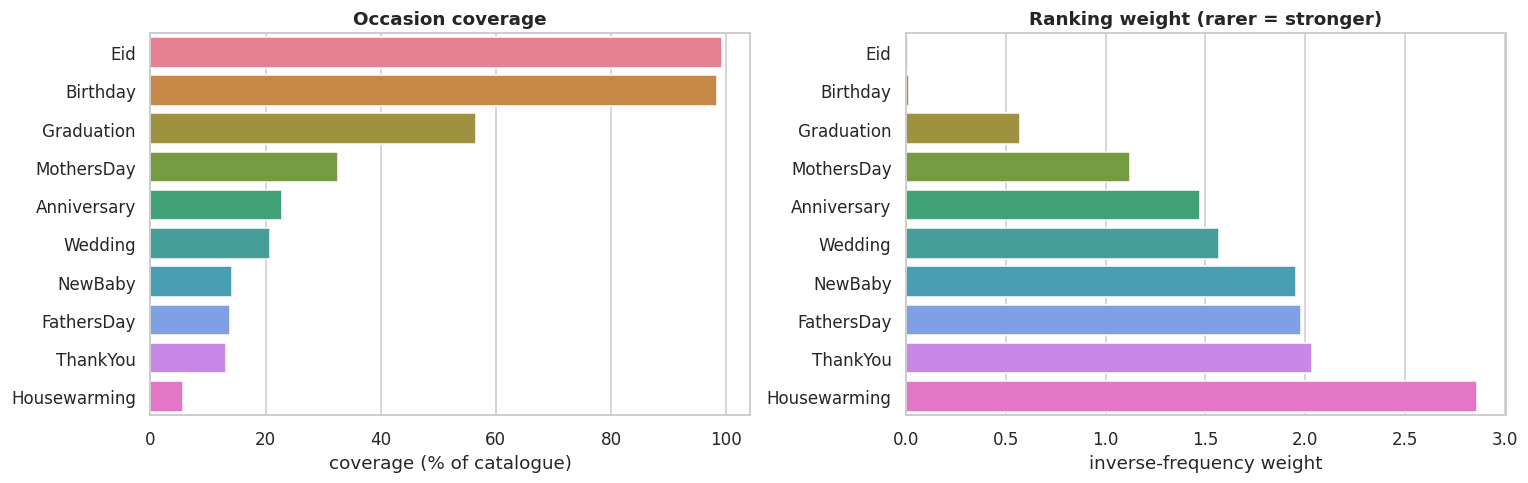

,products,coverage_%,idf_weight
occasion,,,
Eid,44708,99.2,0.008
Birthday,44313,98.4,0.017
Graduation,25460,56.5,0.571
MothersDay,14658,32.5,1.123
Anniversary,10323,22.9,1.474
Wedding,9382,20.8,1.569
NewBaby,6395,14.2,1.952
FathersDay,6238,13.8,1.977
ThankYou,5901,13.1,2.033


In [14]:
occ = pd.DataFrame({
    "products": products[OCC_COLS].sum().values,
    "coverage_%": (products[OCC_COLS].mean() * 100).round(1).values,
    "idf_weight": weights.loc[OCCASIONS, "idf_weight"].values,
}, index=pd.Index(OCCASIONS, name="occasion")).sort_values("coverage_%", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=occ["coverage_%"], y=occ.index, ax=axes[0], hue=occ.index, legend=False)
axes[0].set(xlabel="coverage (% of catalogue)", ylabel="", title="Occasion coverage")

sns.barplot(x=occ["idf_weight"], y=occ.index, ax=axes[1], hue=occ.index, legend=False)
axes[1].set(xlabel="inverse-frequency weight", ylabel="",
            title="Ranking weight (rarer = stronger)")
plt.tight_layout()
save(fig, "10_occasions")
plt.show()

occ

**Reading.** Occasion coverage is extremely uneven. Two labels apply to almost
the entire catalogue, while several apply to a small minority.

**Why it matters.** A label present on nearly every product carries no ranking
information: it cannot separate one candidate from another. The inverse-frequency
weight is what prevents these labels from dominating the score, and it is why the
near-universal labels receive a weight close to zero.

**Improvement.** Never treat occasion match as a binary boost. The modelling team
must multiply every occasion match by its weight, otherwise the two universal
labels will flatten the ranking entirely.

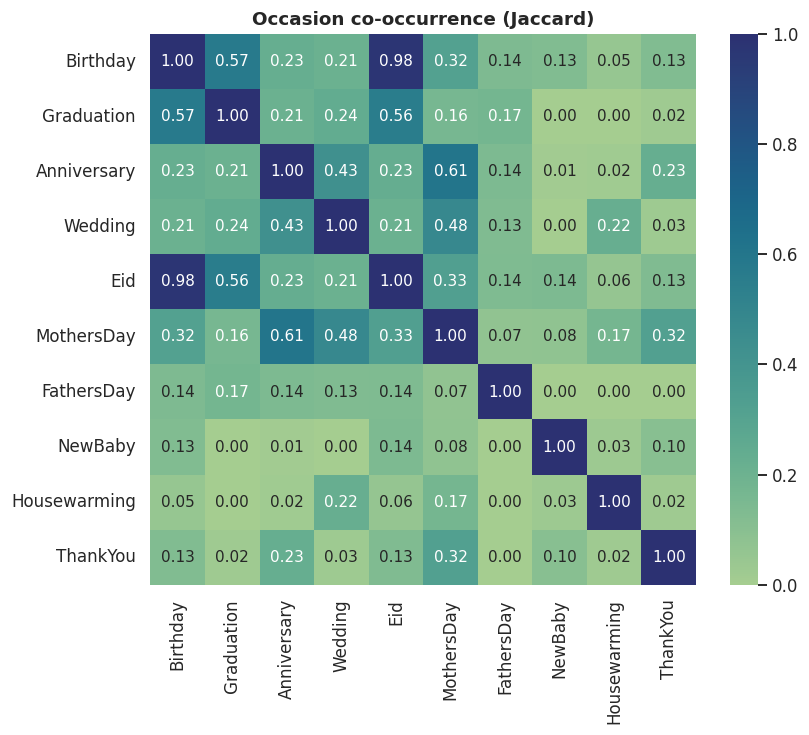

mean occasions per product: 3.77


,products
occasion_count,
1,33
2,4139
3,21914
4,6347
5,6450
6,4945
7,1227


In [15]:
co = products[OCC_COLS].astype(int)
jaccard = pd.DataFrame(index=OCCASIONS, columns=OCCASIONS, dtype=float)
for a in OCCASIONS:
    for b in OCCASIONS:
        inter = (co[f"occ_{a}"] & co[f"occ_{b}"]).sum()
        union = (co[f"occ_{a}"] | co[f"occ_{b}"]).sum()
        jaccard.loc[a, b] = inter / union if union else 0.0

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(jaccard.astype(float), annot=True, fmt=".2f", cmap="crest",
            ax=ax, vmin=0, vmax=1)
ax.set(title="Occasion co-occurrence (Jaccard)")
save(fig, "11_occasion_cooccurrence")
plt.show()

print(f"mean occasions per product: {products['occasion_count'].mean():.2f}")
products["occasion_count"].value_counts().sort_index().to_frame("products")

**Reading.** Several occasion pairs overlap substantially, meaning they select
largely the same products.

**Why it matters.** Highly overlapping labels are close to redundant. If two
occasions almost always co-occur, the system cannot meaningfully distinguish
between those two user intents, and reporting separate per-occasion metrics
overstates how much the model has learned.

**Improvement.** Report per-label metrics alongside the overlap matrix so a
reviewer can see which labels are genuinely distinguishable.

## 9. Interests

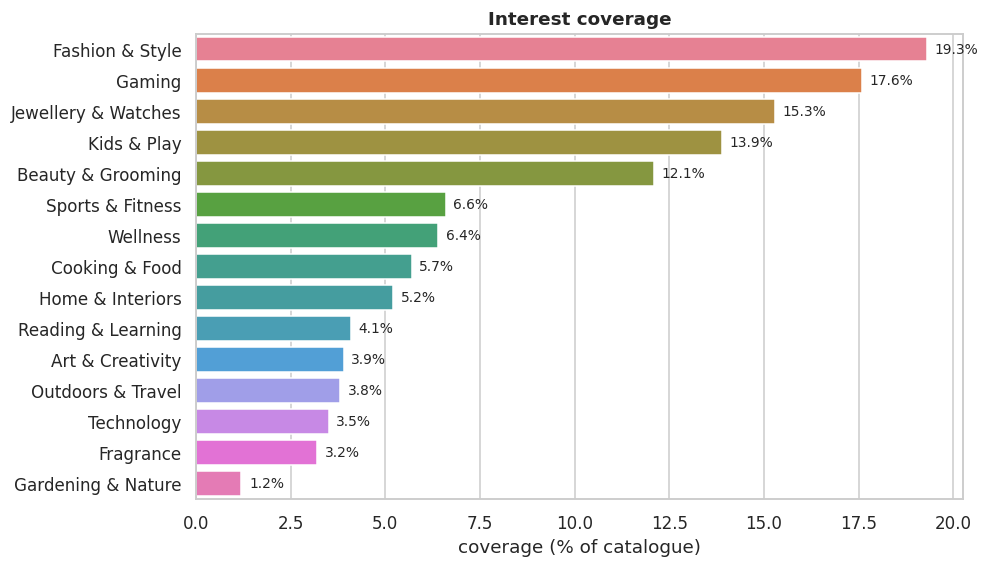

products with no interest tag: 879 (2.0%)


,products,coverage_%,idf_weight
interest,,,
Fashion & Style,8706,19.3,1.644
Gaming,7948,17.6,1.735
Jewellery & Watches,6904,15.3,1.876
Kids & Play,6271,13.9,1.972
Beauty & Grooming,5442,12.1,2.114
Sports & Fitness,2985,6.6,2.714
Wellness,2900,6.4,2.743
Cooking & Food,2550,5.7,2.872
Home & Interiors,2351,5.2,2.953


In [16]:
interest = pd.DataFrame({
    "products": products[INT_COLS].sum().values,
    "coverage_%": (products[INT_COLS].mean() * 100).round(1).values,
    "idf_weight": weights.loc[INTERESTS, "idf_weight"].values,
}, index=pd.Index(INTERESTS, name="interest")).sort_values("coverage_%", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=interest["coverage_%"], y=interest.index, ax=ax,
            hue=interest.index, legend=False)
for i, v in enumerate(interest["coverage_%"]):
    ax.text(v + 0.2, i, f"{v}%", va="center", fontsize=9)
ax.set(xlabel="coverage (% of catalogue)", ylabel="", title="Interest coverage")
save(fig, "12_interests")
plt.show()

print(f"products with no interest tag: {int((products['interest_count'] == 0).sum()):,} "
      f"({(products['interest_count'] == 0).mean() * 100:.1f}%)")
interest

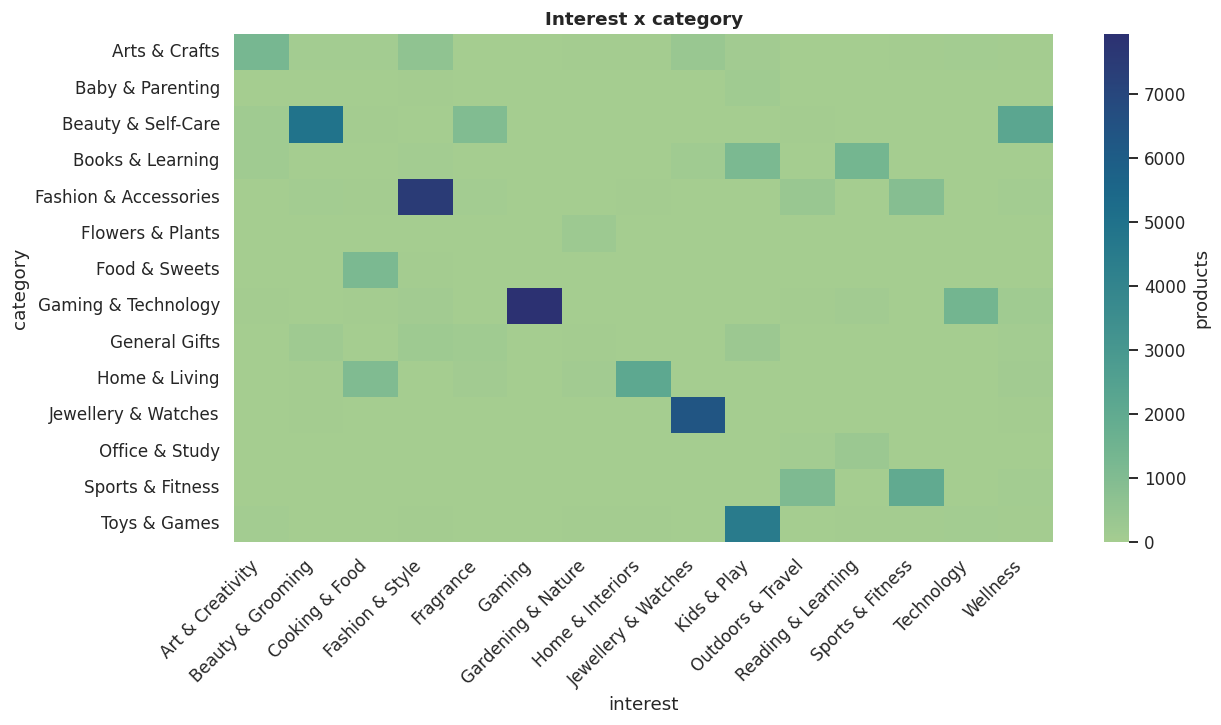

,categories_spanned
Outdoors & Travel,14
Fragrance,13
Beauty & Grooming,13
Wellness,13
Fashion & Style,12
Gardening & Nature,12
Cooking & Food,12
Kids & Play,11
Art & Creativity,10
Home & Interiors,10


In [17]:
spread = pd.DataFrame(
    {i: products.loc[products[f"int_{i}"], "category"].value_counts() for i in INTERESTS}
).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(spread, cmap="crest", ax=ax, cbar_kws={"label": "products"})
ax.set(xlabel="interest", ylabel="category", title="Interest x category")
plt.xticks(rotation=45, ha="right")
save(fig, "13_interest_category")
plt.show()

(spread > 0).sum().sort_values(ascending=False).to_frame("categories_spanned")

**Reading.** Interests spread across many categories rather than mapping
one-to-one onto them.

**Why it matters.** This is the evidence that interest is a genuinely separate
signal and not a renamed copy of category. The raw catalogue shipped an
`Interest Category` column identical to `Category`, which is why it was discarded.
If interest collapsed back onto category, including both features would be pure
redundancy and would double-count the same evidence in the score.

**Improvement.** An interest confined to very few categories is effectively a
category alias; review whether it earns its place as a separate signal.

## 10. Feature associations

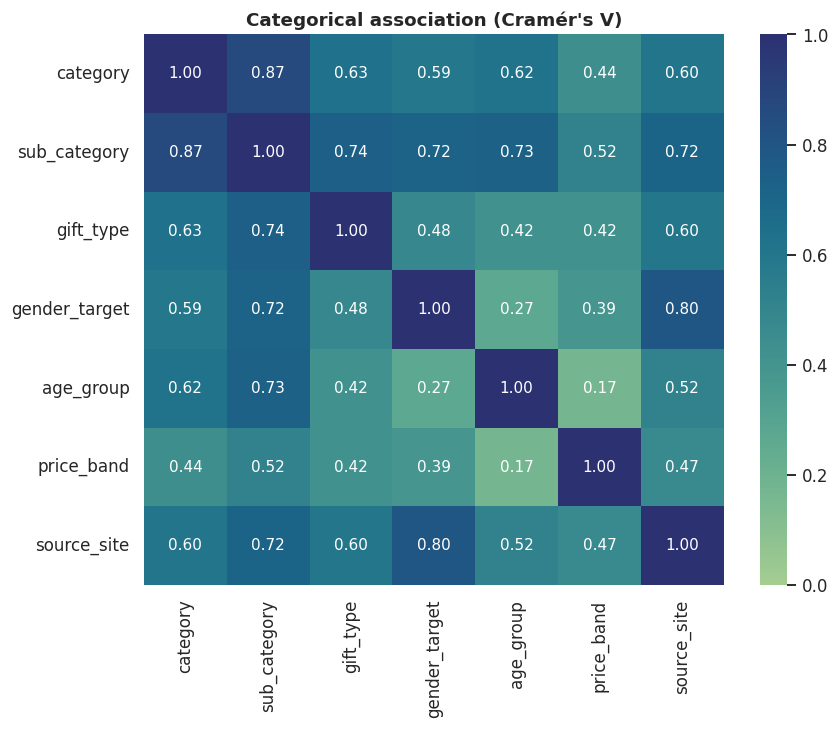

cramers_v
category      sub_category    0.868769
gender_target source_site     0.795299
sub_category  gift_type       0.742270
              age_group       0.732839
              gender_target   0.722140
              source_site     0.717259
category      gift_type       0.634368
              age_group       0.622216

In [18]:
def cramers_v(a: pd.Series, b: pd.Series) -> float:
    table = pd.crosstab(a, b)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    return float(np.sqrt(phi2corr / max(min(kcorr - 1, rcorr - 1), 1e-9)))


cat_features = ["category", "sub_category", "gift_type", "gender_target",
                "age_group", "price_band", "source_site"]
assoc = pd.DataFrame(index=cat_features, columns=cat_features, dtype=float)
for a in cat_features:
    for b in cat_features:
        assoc.loc[a, b] = 1.0 if a == b else cramers_v(products[a], products[b])

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(assoc.astype(float), annot=True, fmt=".2f", cmap="crest",
            vmin=0, vmax=1, ax=ax)
ax.set(title="Categorical association (Cramér's V)")
save(fig, "14_cramers_v")
plt.show()

pairs = (assoc.where(np.triu(np.ones(assoc.shape), k=1).astype(bool))
              .stack().sort_values(ascending=False).head(8))
pairs.to_frame("cramers_v")

**Reading.** Some feature pairs are strongly associated, meaning one largely
determines the other.

**Why it matters.** Strongly associated features are redundant. Including both in
a model double-counts the same evidence and inflates its apparent contribution.
Association with `source_site` is the more serious case: if a feature is
predictable from the store it came from, a model can learn the store rather than
the product, and that will not generalise to a new retailer.

**Improvement.** Drop or combine near-duplicate features, and exclude
`source_site` from any model intended to generalise.

## 11. Source composition and bias

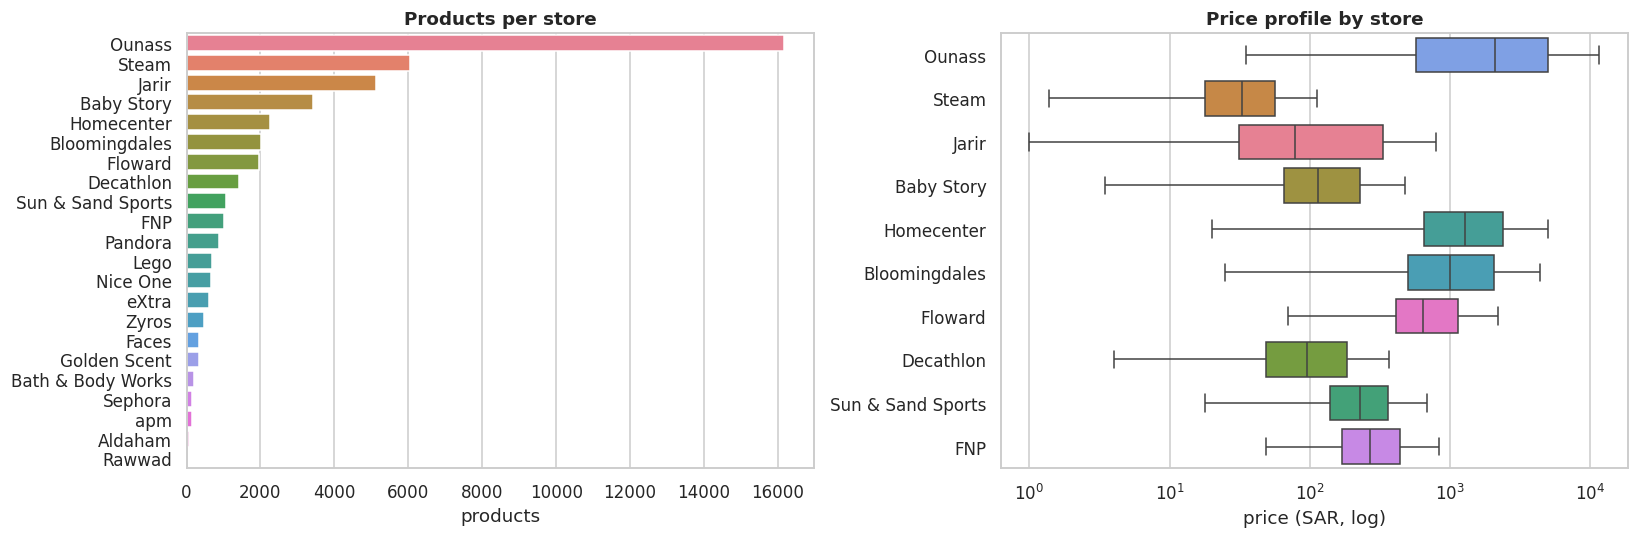

largest store share : 35.9%
top 3 stores share  : 60.6%


,products,share
source_site,,
Ounass,16154,35.9
Steam,6032,13.4
Jarir,5129,11.4
Baby Story,3432,7.6
Homecenter,2268,5.0
Bloomingdales,2006,4.5
Floward,1955,4.3
Decathlon,1421,3.2
Sun & Sand Sports,1079,2.4


In [19]:
store = products["source_site"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=store.values, y=store.index, ax=axes[0], hue=store.index, legend=False)
axes[0].set(xlabel="products", ylabel="", title="Products per store")

top_stores = store.head(10).index
sns.boxplot(data=products[products["source_site"].isin(top_stores)],
            y="source_site", x="price_min", order=top_stores, ax=axes[1],
            showfliers=False, hue="source_site", legend=False)
axes[1].set_xscale("log")
axes[1].set(xlabel="price (SAR, log)", ylabel="", title="Price profile by store")
plt.tight_layout()
save(fig, "15_sources")
plt.show()

top1 = store.iloc[0] / len(products) * 100
top3 = store.head(3).sum() / len(products) * 100
print(f"largest store share : {top1:.1f}%")
print(f"top 3 stores share  : {top3:.1f}%")
store.to_frame("products").assign(share=lambda d: (d["products"] / len(products) * 100).round(1))

**Reading.** Catalogue volume is concentrated in a few stores, and stores
differ sharply in their price profiles.

**Why it matters.** Store concentration becomes catalogue bias: whatever the
dominant stores sell defines what the system can ever recommend, and their price
level skews the whole distribution. Because store correlates with category and
price, `source_site` is a leakage risk as a model feature.

**Improvement.** Report coverage by store during evaluation to confirm that
recommendations are not drawn almost entirely from one retailer.

## 12. Coverage matrix — where the system will fail

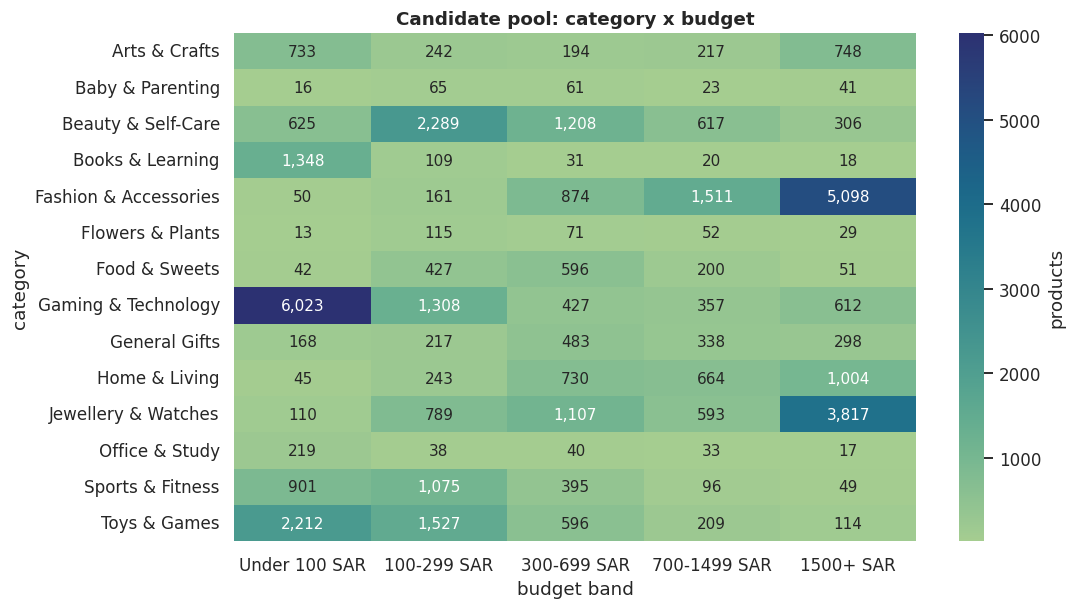

cells below 50 products: 15 of 70


products
category         price_band             
Flowers & Plants Under 100 SAR        13
Baby & Parenting Under 100 SAR        16
Office & Study   1500+ SAR            17
Books & Learning 1500+ SAR            18
                 700-1499 SAR         20
Baby & Parenting 700-1499 SAR         23
Flowers & Plants 1500+ SAR            29
Books & Learning 300-699 SAR          31
Office & Study   700-1499 SAR         33
                 100-299 SAR          38
                 300-699 SAR          40
Baby & Parenting 1500+ SAR            41
Food & Sweets    Under 100 SAR        42
Home & Living    Under 100 SAR        45
Sports & Fitness 1500+ SAR            49

In [20]:
matrix = pd.crosstab(products["category"], products["price_band"])[order]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(matrix, annot=True, fmt=",d", cmap="crest", ax=ax,
            cbar_kws={"label": "products"})
ax.set(xlabel="budget band", ylabel="category",
       title="Candidate pool: category x budget")
save(fig, "16_coverage_matrix")
plt.show()

gaps = (matrix.stack().loc[lambda s: s < 50]
        .sort_values().to_frame("products"))
print(f"cells below 50 products: {len(gaps)} of {matrix.size}")
gaps

**Reading.** The category–budget grid contains cells with very few products.

**Why it matters.** This table is the honest map of where the system fails. When
a user picks a category and a budget landing in a thin cell, the hard filter
leaves almost nothing to rank, and no modelling improvement can fix that. It is a
supply problem, not an algorithm problem.

**Improvement.** Give the modelling team an explicit fallback policy for thin
cells: relax the category first, never the budget or the age floor.

## 13. Data quality flags

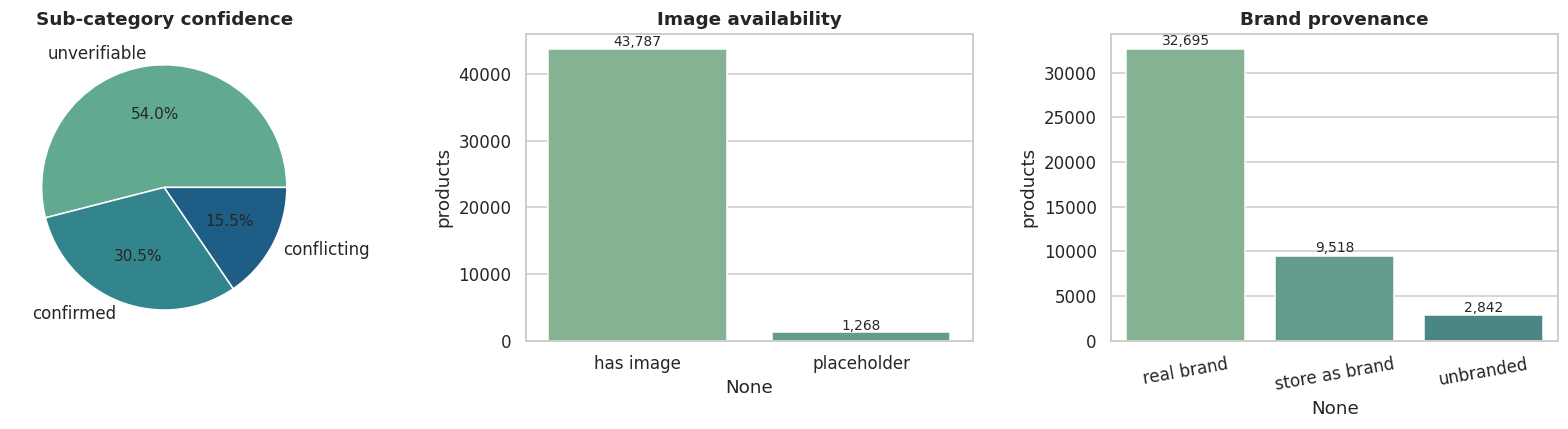

,products,flag
unverifiable,24324,sub-category
confirmed,13760,sub-category
conflicting,6971,sub-category
has image,43787,image
placeholder,1268,image
real brand,32695,brand
store as brand,9518,brand
unbranded,2842,brand


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

conf = products["subcategory_confidence"].value_counts()
axes[0].pie(conf.values, labels=conf.index, autopct="%1.1f%%",
            colors=sns.color_palette(PALETTE, len(conf)))
axes[0].set_title("Sub-category confidence")

img = pd.Series({"has image": int(products["has_image"].sum()),
                 "placeholder": int((~products["has_image"]).sum())})
sns.barplot(x=img.index, y=img.values, ax=axes[1], hue=img.index, legend=False)
for i, v in enumerate(img.values):
    axes[1].text(i, v + 400, f"{v:,}", ha="center", fontsize=9)
axes[1].set(ylabel="products", title="Image availability")

brand = pd.Series({
    "real brand": int(((products["brand"] != "Unbranded") & ~products["brand_is_store"]).sum()),
    "store as brand": int(products["brand_is_store"].sum()),
    "unbranded": int((products["brand"] == "Unbranded").sum()),
})
sns.barplot(x=brand.index, y=brand.values, ax=axes[2], hue=brand.index, legend=False)
for i, v in enumerate(brand.values):
    axes[2].text(i, v + 400, f"{v:,}", ha="center", fontsize=9)
axes[2].set(ylabel="products", title="Brand provenance")
plt.xticks(rotation=10)
plt.tight_layout()
save(fig, "17_quality_flags")
plt.show()

pd.concat([conf.to_frame("products").assign(flag="sub-category"),
           img.to_frame("products").assign(flag="image"),
           brand.to_frame("products").assign(flag="brand")])

**Reading.** A meaningful share of products carries a sub-category that the
product name does not corroborate, some products have no image, and a portion has
no genuine brand.

**Why it matters.** `conflicting` is a weak signal, not proof of error: a LEGO set
is a toy without containing the word *toy*. It should demote a product in ranking,
never delete or relabel it. Products without an image should also be demoted
rather than removed, since dropping them would shrink coverage.

**Improvement.** Work through `subcategory_audit_rows.csv` starting with the
largest flagged sub-categories; a small manual pass covers most of the affected
volume.

## 14. Product names

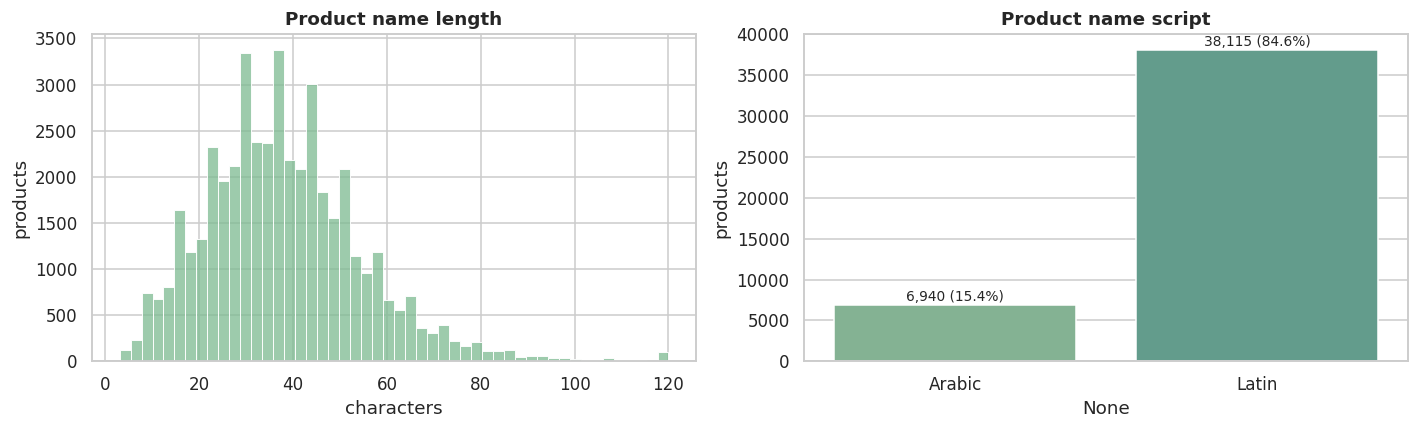

median name length: 37 characters
duplicate names   : 235


In [22]:
names = products["product_name"].astype(str)
arabic = names.str.contains(r"[\u0600-\u06FF]", regex=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(names.str.len().clip(0, 120), bins=50, ax=axes[0])
axes[0].set(xlabel="characters", ylabel="products", title="Product name length")

lang = pd.Series({"Arabic": int(arabic.sum()), "Latin": int((~arabic).sum())})
sns.barplot(x=lang.index, y=lang.values, ax=axes[1], hue=lang.index, legend=False)
for i, v in enumerate(lang.values):
    axes[1].text(i, v + 400, f"{v:,} ({v / len(products) * 100:.1f}%)",
                 ha="center", fontsize=9)
axes[1].set(ylabel="products", title="Product name script")
plt.tight_layout()
save(fig, "18_product_names")
plt.show()

print(f"median name length: {names.str.len().median():.0f} characters")
print(f"duplicate names   : {int(names.duplicated().sum()):,}")

**Reading.** Product names are short and the catalogue is bilingual.

**Why it matters.** Name is the only free-text field with independent semantic
content, because the description column is template-generated from the structured
fields and therefore adds nothing a model cannot already read. Any text model must
handle both scripts; an English-only tokeniser would discard the Arabic portion of
the catalogue entirely.

**Improvement.** Use a multilingual encoder, and normalise Arabic letter variants
before matching.

## 15. Findings for the modelling team

In [23]:
findings = pd.DataFrame([
    ("Price is heavily right-skewed",
     "Use log(price) or the ordinal price_band; never raw price in a distance metric",
     "high"),
    ("Price scale differs by category",
     "Normalise price fit within category, not globally",
     "high"),
    ("Category sizes are highly unequal",
     "Macro-average all metrics; apply class weights; cap results per category",
     "high"),
    ("Two occasion labels are near-universal",
     "Multiply every occasion match by its inverse-frequency weight",
     "critical"),
    ("Occasion labels are rule-derived, not observed",
     "Do not train a model on them and evaluate against them; that is circular",
     "critical"),
    ("Description is template-generated",
     "Exclude it from text features; embed product_name instead",
     "critical"),
    ("Catalogue is bilingual",
     "Use a multilingual encoder and fold Arabic letter variants",
     "high"),
    ("source_site correlates with category and price",
     "Exclude source_site as a model feature; keep it for bias reporting only",
     "critical"),
    ("Age-gender and category-budget grids contain thin cells",
     "Evaluate per cell; relax category on fallback, never budget or age",
     "high"),
    ("Sub-category is unverifiable for many products",
     "Use subcategory_confidence to demote, never to delete or relabel",
     "medium"),
    ("A share of products has no image",
     "Read image_display_url only; demote placeholder products in ranking",
     "medium"),
    ("Products group into parent and options",
     "Rank parent products; resolve options at the interface layer",
     "high"),
], columns=["finding", "action for the modelling team", "priority"])

findings.to_csv(DATA_DIR / "eda_findings.csv", index=False, encoding="utf-8-sig")
findings.style.hide(axis="index")

finding,action for the modelling team,priority
Price is heavily right-skewed,Use log(price) or the ordinal price_band; never raw price in a distance metric,high
Price scale differs by category,"Normalise price fit within category, not globally",high
Category sizes are highly unequal,Macro-average all metrics; apply class weights; cap results per category,high
Two occasion labels are near-universal,Multiply every occasion match by its inverse-frequency weight,critical
"Occasion labels are rule-derived, not observed",Do not train a model on them and evaluate against them; that is circular,critical
Description is template-generated,Exclude it from text features; embed product_name instead,critical
Catalogue is bilingual,Use a multilingual encoder and fold Arabic letter variants,high
source_site correlates with category and price,Exclude source_site as a model feature; keep it for bias reporting only,critical
Age-gender and category-budget grids contain thin cells,"Evaluate per cell; relax category on fallback, never budget or age",high
Sub-category is unverifiable for many products,"Use subcategory_confidence to demote, never to delete or relabel",medium


## 16. Saved figures

In [24]:
figures = sorted(FIG_DIR.glob("*.png"))
pd.DataFrame({
    "figure": [f.name for f in figures],
    "KB": [round(f.stat().st_size / 1024, 1) for f in figures],
})

,figure,KB
0,01_missing_values.png,28.1
1,02_purchase_options.png,74.8
2,03_price_distribution.png,107.9
3,04_price_bands.png,102.8
4,05_price_by_category.png,121.1
5,06_categories.png,164.7
6,07_subcategories.png,137.6
7,08_demographics.png,90.5
8,09_age_gender_heatmap.png,110.5
9,10_occasions.png,95.5
